In [ ]:
%pip uninstall -y pyiss
%pip install "pyiss @ git+https://github.com/ArnaudMath/pyiss.git"


In [ ]:
# # Local development path (skip this cell if you pip-installed pyiss)
# import sys
# from pathlib import Path

# root = Path("..").resolve()
# sys.path.insert(0, str(root / "src"))

In [3]:
import pyiss as iss

set1 = iss.infer_set("co-iss-n1540315886")
# set2 = iss.infer_set("co-iss-n1823513381")
# set3 = iss.infer_set("co-iss-w1540365932"), set4 = ...
set1

In [4]:
print("size:", set1.size)
print("available_filters:", set1.available_filters)
print("time_window:", set1.time_window)
print("duration_s:", set1.time_window.duration_s)

size: 34
available_filters: ['CB3+IRP0', 'CB3', 'UV1', 'UV2', 'UV3', 'UV3+P0', 'UV3+P60', 'UV3+P120', 'BL2+P0', 'BL2+P60', 'BL2+P120', 'MT1+P0', 'MT1+P60', 'MT1+P120', 'MT1', 'CB1', 'CB1+P120', 'CB1+P60', 'CB1+P0', 'CB2+P0', 'CB2+P60', 'CB2+P120', 'CB2+IRP0', 'CB2', 'MT2', 'MT2+IRP0', 'BL1', 'GRN', 'RED', 'MT3', 'MT3+IRP0']
time_window: TimeWindow(start=Timestamp('2006-10-23 16:37:23.689000+0000', tz='UTC'), end=Timestamp('2006-10-23 17:12:49.749000+0000', tz='UTC'))
duration_s: 2126.06


In [5]:
f0 = set1.available_filters[0]
print("example filter:", f0)

# Use filter() + metadata() to access observation details
print(set1.filter(f0).metadata("opusid", "time1", "target"))

example filter: CB3+IRP0
               opusid                            time1 target
0  co-iss-n1540314614 2006-10-23 16:37:23.689000+00:00  Titan
1  co-iss-n1540316496 2006-10-23 17:08:45.743000+00:00  Titan


In [6]:
set1.df

,opusid,time1,target,COISSfilter
0,co-iss-n1540314614,2006-10-23 16:37:23.689000+00:00,Titan,CB3+IRP0
1,co-iss-n1540314702,2006-10-23 16:38:59.688000+00:00,Titan,CB3
2,co-iss-n1540314822,2006-10-23 16:40:15.695000+00:00,Titan,UV1
3,co-iss-n1540314894,2006-10-23 16:42:03.699000+00:00,Titan,UV2
4,co-iss-n1540314950,2006-10-23 16:43:19.702000+00:00,Titan,UV3
5,co-iss-n1540315070,2006-10-23 16:44:49.706000+00:00,Titan,UV3+P0
6,co-iss-n1540315174,2006-10-23 16:46:33.705000+00:00,Titan,UV3+P60
7,co-iss-n1540315278,2006-10-23 16:48:17.704000+00:00,Titan,UV3+P120
8,co-iss-n1540315334,2006-10-23 16:49:37.712000+00:00,Titan,BL2+P0
9,co-iss-n1540315390,2006-10-23 16:50:33.711000+00:00,Titan,BL2+P60


In [7]:
# Here you can check if it is indeed a bounded set.
# It is a more elaborate version of df, but with more context:
# Row A shows the last images of the set before,
# and row Z shows the first images of the very next set
set1.diagnostic_window()

,_role,opusid,time1,target,COISSfilter,dt_prev_s,dt_next_s
0,A,co-iss-n1540198398,2006-10-22 08:16:54.466000+00:00,Star,RED,NaN,116429.223
1,set,co-iss-n1540314614,2006-10-23 16:37:23.689000+00:00,Titan,CB3+IRP0,116429.223,95.999
2,set,co-iss-n1540314702,2006-10-23 16:38:59.688000+00:00,Titan,CB3,95.999,76.007
3,set,co-iss-n1540314822,2006-10-23 16:40:15.695000+00:00,Titan,UV1,76.007,108.004
4,set,co-iss-n1540314894,2006-10-23 16:42:03.699000+00:00,Titan,UV2,108.004,76.003
5,set,co-iss-n1540314950,2006-10-23 16:43:19.702000+00:00,Titan,UV3,76.003,90.004
6,set,co-iss-n1540315070,2006-10-23 16:44:49.706000+00:00,Titan,UV3+P0,90.004,103.999
7,set,co-iss-n1540315174,2006-10-23 16:46:33.705000+00:00,Titan,UV3+P60,103.999,103.999
8,set,co-iss-n1540315278,2006-10-23 16:48:17.704000+00:00,Titan,UV3+P120,103.999,80.008
9,set,co-iss-n1540315334,2006-10-23 16:49:37.712000+00:00,Titan,BL2+P0,80.008,55.999


In [8]:
set1.show()  # all previews

In [9]:
set1.show("MT1") # You can chose a filter of your liking


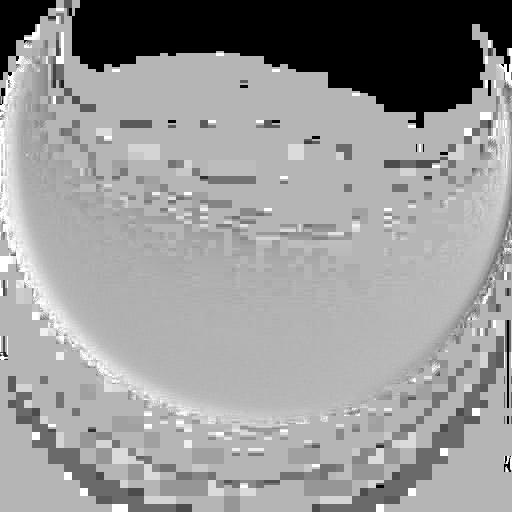

In [10]:
# Simple image ratio: divide one filter by another
pair = set1.pair("MT1", "CB1")
ratio = pair.divide()
ratio.show()